In [1]:
import sys
sys.path.append('src')

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from graph import Graph
from dijkstra import dijkstra
from prim import prim
from bellman_ford import bellman_ford

print("Imports successful")

Imports successful


# Comparison and Analysis

## Theoretical Time & Space Complexity

In [2]:
complexity = pd.DataFrame([
    {"Algorithm": "Dijkstra's", "Time Complexity": "O((V + E) log V)", "Space Complexity": "O(V + E)",
     "Handles Negative Weights": "No (raises error / undefined behaviour)",
     "Detects Negative Cycles": "No"},
    {"Algorithm": "Prim's (MST)", "Time Complexity": "O(E log V)", "Space Complexity": "O(V + E)",
     "Handles Negative Weights": "Yes (MST doesn't require non-negative weights)",
     "Detects Negative Cycles": "N/A (MST has no concept of cycles/negative cycles)"},
    {"Algorithm": "Bellman-Ford", "Time Complexity": "O(V × E)", "Space Complexity": "O(V + E)",
     "Handles Negative Weights": "Yes",
     "Detects Negative Cycles": "Yes"},
])
complexity

,Algorithm,Time Complexity,Space Complexity,Handles Negative Weights,Detects Negative Cycles
0,Dijkstra's,O((V + E) log V),O(V + E),No (raises error / undefined behaviour),No
1,Prim's (MST),O(E log V),O(V + E),Yes (MST doesn't require non-negative weights),N/A (MST has no concept of cycles/negative cyc...
2,Bellman-Ford,O(V × E),O(V + E),Yes,Yes


## Empirical Testing: Dense vs Sparse Graphs

- **Sparse graph**: edges ≈ V (each node connects to a small, fixed number of neighbors) — representative of a real road network.
- **Dense graph**: edges ≈ V² / 4 (each node connects to a large fraction of other nodes) — representative of, e.g., a fully-interconnected flight network.

We keep all weights non-negative so Dijkstra's can run on every graph (needed for a fair 3-way comparison); a separate negative-weight test is done afterward for Bellman-Ford only.

In [3]:
def generate_sparse_graph(n_nodes, avg_degree=3, seed=42):
    """Sparse graph: ~n_nodes * avg_degree edges."""
    rng = random.Random(seed)
    g = Graph()
    node_names = [f"N{i}" for i in range(n_nodes)]
    for name in node_names:
        g.add_node(name)

    for i, u in enumerate(node_names):
        # connect to avg_degree random other nodes (mostly "nearby" indices to mimic locality)
        possible_targets = [n for n in node_names if n != u]
        targets = rng.sample(possible_targets, min(avg_degree, len(possible_targets)))
        for v in targets:
            weight = rng.randint(1, 100)
            g.add_edge(u, v, weight)
    return g


def generate_dense_graph(n_nodes, density=0.5, seed=42):
    """Dense graph: each pair of nodes connected with probability = density."""
    rng = random.Random(seed)
    g = Graph()
    node_names = [f"N{i}" for i in range(n_nodes)]
    for name in node_names:
        g.add_node(name)

    for u in node_names:
        for v in node_names:
            if u != v and rng.random() < density:
                weight = rng.randint(1, 100)
                g.add_edge(u, v, weight)
    return g


# Build test graphs at a few sizes
graph_sizes = [50, 100, 200]
sparse_graphs = {n: generate_sparse_graph(n) for n in graph_sizes}
dense_graphs = {n: generate_dense_graph(n) for n in graph_sizes}

for n in graph_sizes:
    print(f"n={n}: sparse has {sparse_graphs[n].num_edges()} edges, dense has {dense_graphs[n].num_edges()} edges")

n=50: sparse has 150 edges, dense has 1230 edges
n=100: sparse has 300 edges, dense has 4990 edges
n=200: sparse has 600 edges, dense has 19998 edges


In [4]:
def time_dijkstra(graph):
    source = graph.nodes()[0]
    t0 = time.perf_counter()
    dijkstra(graph, source)
    return time.perf_counter() - t0


def time_prim(graph):
    t0 = time.perf_counter()
    prim(graph)
    return time.perf_counter() - t0


def time_bellman_ford(graph):
    source = graph.nodes()[0]
    t0 = time.perf_counter()
    bellman_ford(graph, source)
    return time.perf_counter() - t0


results = []

for n in graph_sizes:
    for graph_type, graph_dict in [("Sparse", sparse_graphs), ("Dense", dense_graphs)]:
        graph = graph_dict[n]
        v, e = graph.num_nodes(), graph.num_edges()

        dij_time = time_dijkstra(graph)
        prim_time = time_prim(graph)
        bf_time = time_bellman_ford(graph)

        results.append({"n": n, "type": graph_type, "V": v, "E": e,
                         "Dijkstra_ms": dij_time * 1000,
                         "Prim_ms": prim_time * 1000,
                         "BellmanFord_ms": bf_time * 1000})

    print(f"Completed timing for n={n}")

df_results = pd.DataFrame(results)
df_results

Completed timing for n=50
Completed timing for n=100
Completed timing for n=200


,n,type,V,E,Dijkstra_ms,Prim_ms,BellmanFord_ms
0,50,Sparse,50,150,0.102958,0.134833,0.134000
1,50,Dense,50,1230,0.178417,0.745958,0.888125
2,100,Sparse,100,300,0.300791,0.513250,0.738458
3,100,Dense,100,4990,1.026125,3.979625,6.061500
4,200,Sparse,200,600,0.300000,0.594500,0.996667
5,200,Dense,200,19998,2.109375,9.069750,16.124125


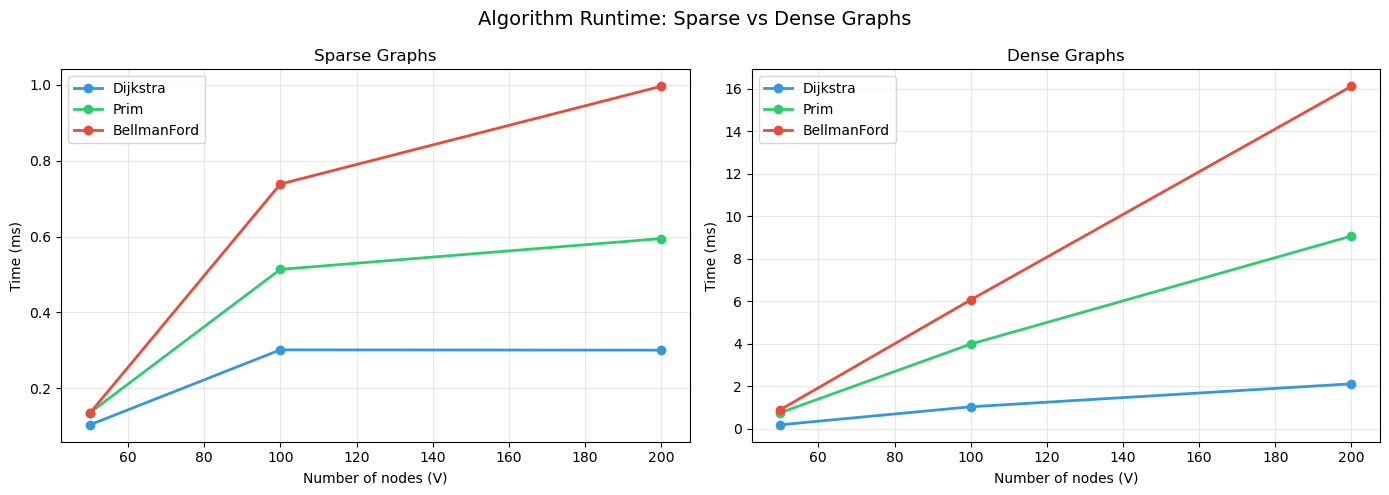

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
algorithms = ["Dijkstra_ms", "Prim_ms", "BellmanFord_ms"]
colors = {"Dijkstra_ms": "#3498db", "Prim_ms": "#2ecc71", "BellmanFord_ms": "#e74c3c"}

for ax, graph_type in zip(axes, ["Sparse", "Dense"]):
    sub = df_results[df_results["type"] == graph_type]
    for algo in algorithms:
        ax.plot(sub["n"], sub[algo], marker='o', label=algo.replace("_ms", ""),
                 color=colors[algo], linewidth=2)
    ax.set_xlabel("Number of nodes (V)")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"{graph_type} Graphs")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Algorithm Runtime: Sparse vs Dense Graphs", fontsize=14)
plt.tight_layout()
plt.show()

## Big-O vs Observed Constant Factor

Big-O notation predicts *growth rate*, not actual wall-clock time — it hides
a constant factor that our empirical results make clearly visible.

**Dijkstra's vs Prim's — same O(E log V) family, different real speed.**
On the dense n=200 graph, Dijkstra's took ~2.1ms while Prim's took ~9.1ms —
roughly **4x slower**, despite both having the same theoretical complexity
class (O(E log V)). The difference comes from implementation detail, not
algorithm class: our Prim's implementation pushes a heap entry for *every*
outgoing edge of the newly visited node on every iteration (rather than
using a decrease-key operation), producing more total heap operations in
practice on dense graphs. This is exactly the kind of constant-factor gap
Big-O notation does not capture.

**Bellman-Ford's O(V×E) is visibly worse on dense graphs — as theory predicts,
but the *scale* of the gap is only visible empirically.** Going from sparse
(V=200, E=600) to dense (V=200, E=19,998) — roughly a 33x increase in edges —
Bellman-Ford's time increased from ~1.0ms to ~16.1ms, about **16x slower**.
This is broadly consistent with its O(V×E) dependence on edge count, but the
theoretical complexity alone doesn't tell you *how many milliseconds* that
translates to for a given implementation and hardware — only empirical
measurement does.

**Practical significance.** We should not claim "Bellman-Ford is O(V×E) and
Dijkstra's is O((V+E) log V), so Bellman-Ford will always be roughly V/log V
times slower" — that ratio only holds up to a constant factor that depends
on implementation details (data structures used, language overhead, hardware)
and is not something Big-O notation promises to predict. Our results confirm
Bellman-Ford is meaningfully slower on dense graphs, but the *exact* multiple
(16x here) is an empirical finding, not a value derivable from the Big-O
expressions alone.

## Handling of Negative Weights — Summary

| Algorithm | Negative weights | Negative cycle detection | Notes |
|---|---|---|---|
| **Dijkstra's** | Not supported | N/A | Our implementation explicitly raises an error rather than silently returning an incorrect result (demonstrated in `04_bellman_ford.ipynb`, Sanity Test 2) — a deliberate design choice, since the greedy "finalize the closest node" strategy is provably incorrect once negative edges exist. |
| **Prim's (MST)** | Supported | N/A | MST construction doesn't involve path *distances* accumulating along a route the way shortest-path algorithms do, so negative weights don't break correctness — Prim's just picks the globally minimum-weight edges. There's no equivalent notion of a "negative cycle" for an MST, since it's a tree with no cycles by definition. |
| **Bellman-Ford** | Supported | Supported | The only one of the three that correctly computes shortest paths with negative edges (demonstrated: `04_bellman_ford.ipynb`, Sanity Test 2), and the only one that can detect when the problem is undefined due to a negative cycle (Sanity Test 3). This robustness comes at the cost of O(V×E) time — significantly slower than Dijkstra's on graphs where all weights happen to be non-negative. |

**Practical implication for route planning:** if all road costs/times are
guaranteed non-negative (the normal case), Dijkstra's is the clear choice —
our data shows it is consistently the fastest of the three across both
sparse and dense graphs. Bellman-Ford's slower speed only becomes worth
paying if the network can have genuinely negative edge weights (e.g. toll
rebates, promotional route discounts) or if verifying the absence of a
negative cycle is itself a required safety check.